# AdventureWorks Business Analysis

**Goal:** answer five sales questions with SQL as the primary analytical tool. Python is used for focused exploration, Pareto analysis, segment profiling, and charts.

**Dataset grain:** one row in `FactInternetSales` is one order line (`SalesOrderNumber` × `SalesOrderLineNumber`).

**Scope note:** this is a fictional sample dataset. Findings are descriptive; recommendations are framed as hypotheses that require additional business data.

In [1]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
import psycopg

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})

cwd = Path.cwd()
PROJECT_ROOT = next((p for p in [cwd, *cwd.parents] if (p / "sql" / "02_analysis.sql").exists()), cwd)
CHART_DIR = PROJECT_ROOT / "charts"
CHART_DIR.mkdir(exist_ok=True)

conn = psycopg.connect(
    host=os.environ.get("PGHOST", "127.0.0.1"),
    port=os.environ.get("PGPORT", "54320"),
    dbname=os.environ.get("PGDATABASE", "olist"),
    user=os.environ.get("PGUSER", "postgres"),
    password=os.environ.get("PGPASSWORD", "postgres"),
)

def sql(query):
    return pd.read_sql(query, conn)

fact = sql("SELECT * FROM analytics.fact_sales")
products = sql("SELECT * FROM analytics.product_dim")
print(f"Fact rows: {len(fact):,}")
print(f"Date range: {fact.orderdate.min()} to {fact.orderdate.max()}")
print(f"Distinct orders: {fact.salesordernumber.nunique():,}")

/tmp/ipykernel_94074/2098753172.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


Fact rows: 60,398
Date range: 2010-12-29 to 2014-01-28
Distinct orders: 27,659


## 1. What is associated with monthly revenue differences?

SQL aggregates orders by calendar month and compares revenue, AOV, average price per item, and items per order. Month totals pool multiple years, so this is a descriptive monthly pattern rather than a causal seasonality estimate.

In [2]:
q1 = sql("SELECT * FROM analytics.q1_revenue_drivers ORDER BY month")
q1[["month_name", "revenue", "total_line_items", "avg_items_per_order", "avg_price_per_item", "aov"]]

/tmp/ipykernel_94074/2098753172.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,month_name,revenue,total_line_items,avg_items_per_order,avg_price_per_item,aov
0,January,"1,868,572.67","4,028.00",2.12,463.90,983.98
1,February,"1,744,677.83","3,857.00",2.11,452.34,955.99
2,March,"1,908,589.05","4,449.00",2.17,428.99,930.11
3,April,"1,948,432.23","4,355.00",2.19,447.40,980.10
4,May,"2,205,152.30","4,780.00",2.20,461.33,"1,014.80"
5,June,"2,936,177.74","5,573.00",2.18,526.86,"1,149.19"
6,July,"2,412,980.59","5,105.00",2.21,472.67,"1,045.03"
7,August,"2,689,540.88","5,352.00",2.18,502.53,"1,096.43"
8,September,"2,536,756.64","5,070.00",2.17,500.35,"1,085.01"
9,October,"2,916,660.90","5,834.00",2.19,499.94,"1,094.43"


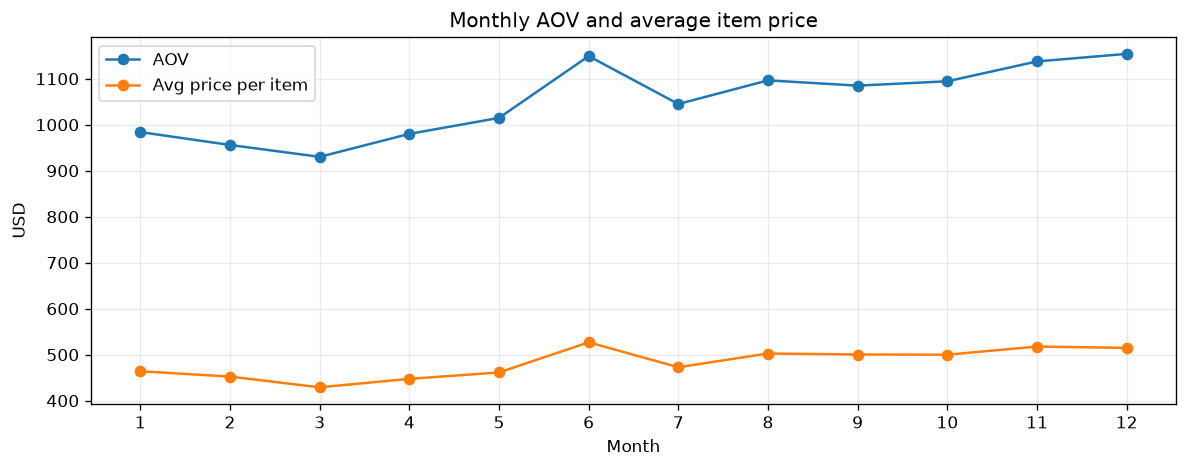

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(q1["month"], q1["aov"], marker="o", label="AOV")
ax.plot(q1["month"], q1["avg_price_per_item"], marker="o", label="Avg price per item")
ax.set(title="Monthly AOV and average item price", xlabel="Month", ylabel="USD", xticks=range(1, 13))
ax.legend()
fig.tight_layout()
fig.savefig(CHART_DIR / "q1_revenue_drivers.png", bbox_inches="tight")
plt.show()

**Observation:** items per order remain close to 2.1 across months, while AOV and average item price vary more.

**Interpretation:** the observed monthly revenue pattern was not driven by customers buying more items per order. Product mix and price are plausible explanations, but the aggregate does not separate them.

**Data needed before action:** product-level mix by month, promotions/discounts, list-price changes, and inventory availability.

## 2. Which category–territory combinations contributed to 2012→2013 growth?

SQL pivots full-year revenue by category and territory, then calculates absolute change, relative change, and contribution to total change.

In [4]:
q2 = sql("SELECT * FROM analytics.q2_contribution_to_change ORDER BY contribution_to_change_pct DESC")
q2.head(10)

/tmp/ipykernel_94074/2098753172.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,category,territory,revenue_2012,revenue_2013,absolute_change,relative_change_pct,contribution_to_change_pct
0,Bikes,United States,"1,436,441.91","5,090,298.55","3,653,856.64",254.37,34.77
1,Bikes,Australia,"2,127,687.02","4,139,720.96","2,012,033.94",94.56,19.15
2,Bikes,United Kingdom,"712,341.53","2,019,210.81","1,306,869.28",183.46,12.44
3,Bikes,Germany,"608,121.86","1,679,892.32","1,071,770.46",176.24,10.20
4,Bikes,France,"647,605.44","1,491,724.96","844,119.52",130.34,8.03
5,Bikes,Canada,"307,497.56","938,654.76","631,157.20",205.26,6.01
6,Accessories,United States,435.36,"244,600.46","244,165.10","56,083.49",2.32
7,Accessories,Australia,573.99,"132,763.21","132,189.22","23,029.88",1.26
8,Clothing,United States,171.46,"127,179.85","127,008.39","74,074.65",1.21
9,Accessories,Canada,56.97,"96,922.04","96,865.07","170,028.21",0.92


**Observation:** Bikes account for most of the measured increase, led by the United States and Australia. Accessories show very large percentage growth from a small 2012 base.

**Hypothesis:** the growth may reflect demand, wider availability, product launches, or commercial activity; the sales table alone cannot distinguish these causes.

**Data needed before action:** campaign history, inventory/stockouts, launch dates, channel mix, and regional market context.

## 3. How concentrated is product revenue? (Pareto)

This is the main Python calculation: aggregate revenue by product name, rank products, and calculate cumulative revenue share.

In [5]:
product_revenue = (
    fact[["productkey", "salesamount"]]
    .merge(products[["productkey", "englishproductname", "product_category_name"]], on="productkey", how="left")
    .groupby(["englishproductname", "product_category_name"], as_index=False)
    .agg(revenue=("salesamount", "sum"))
    .sort_values("revenue", ascending=False)
    .reset_index(drop=True)
)
product_revenue["cumulative_share"] = product_revenue["revenue"].cumsum() / product_revenue["revenue"].sum()
cutoff = max(1, int(len(product_revenue) * 0.20))
top20_share = product_revenue.loc[cutoff - 1, "cumulative_share"]
print(f"Products sold: {len(product_revenue)}")
print(f"Top 20% ({cutoff} products): {top20_share:.1%} of revenue")
product_revenue.head(10)

Products sold: 130
Top 20% (26 products): 70.8% of revenue


,englishproductname,product_category_name,revenue,cumulative_share
0,"Mountain-200 Black, 46",Bikes,"1,373,469.55",0.05
1,"Mountain-200 Black, 42",Bikes,"1,363,142.09",0.09
2,"Mountain-200 Silver, 38",Bikes,"1,339,462.79",0.14
3,"Mountain-200 Silver, 46",Bikes,"1,301,100.10",0.18
4,"Mountain-200 Black, 38",Bikes,"1,294,866.14",0.23
5,"Mountain-200 Silver, 42",Bikes,"1,257,434.57",0.27
6,"Road-150 Red, 48",Bikes,"1,205,876.99",0.31
7,"Road-150 Red, 62",Bikes,"1,202,298.72",0.35
8,"Road-150 Red, 52",Bikes,"1,080,637.54",0.39
9,"Road-150 Red, 56",Bikes,"1,055,589.65",0.42


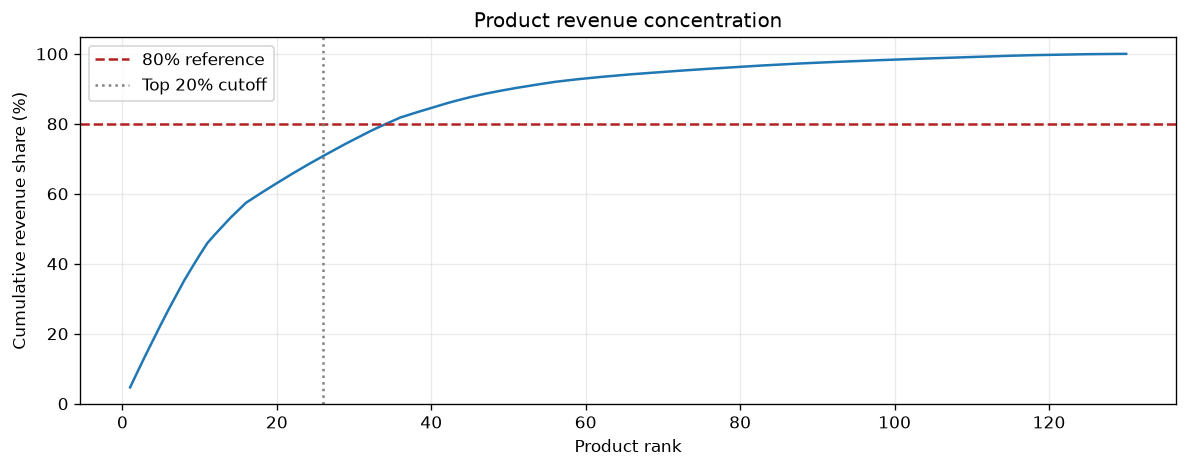

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(product_revenue) + 1), product_revenue["cumulative_share"] * 100)
ax.axhline(80, color="firebrick", linestyle="--", label="80% reference")
ax.axvline(cutoff, color="grey", linestyle=":", label="Top 20% cutoff")
ax.set(title="Product revenue concentration", xlabel="Product rank", ylabel="Cumulative revenue share (%)")
ax.legend()
fig.tight_layout()
fig.savefig(CHART_DIR / "q3_pareto_products.png", bbox_inches="tight")
plt.show()

**Observation:** the top 20% of product names generate about 70.8% of revenue.

**Hypothesis:** these products may deserve closer availability monitoring, but revenue concentration alone does not determine stocking policy.

**Data needed before action:** stockouts, lead times, holding costs, service levels, demand volatility, and product substitution.

## 4. What customer groups appear in an RFM-style segmentation?

SQL assigns revenue, frequency, and recency quintiles. A higher recency score means a more recent purchase. Python profiles the resulting groups; it does not recalculate every SQL KPI.

In [7]:
segments = sql("""
SELECT segment,
       COUNT(*) AS customers,
       SUM(total_revenue) AS revenue,
       AVG(total_revenue) AS avg_customer_revenue,
       MIN(last_order_date) AS oldest_last_order,
       MAX(last_order_date) AS newest_last_order
FROM analytics.q4_customer_segments
GROUP BY segment
ORDER BY revenue DESC
""")
recency_check = sql("""
SELECT recency_quintile, MIN(last_order_date) AS min_date, MAX(last_order_date) AS max_date, COUNT(*) AS customers
FROM analytics.q4_customer_segments
GROUP BY recency_quintile
ORDER BY recency_quintile
""")
print("Recency direction check (score 5 must contain the newest dates):")
display(recency_check)
segments

/tmp/ipykernel_94074/2098753172.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


Recency direction check (score 5 must contain the newest dates):


,recency_quintile,min_date,max_date,customers
0,1,2010-12-29,2013-04-16,3697
1,2,2013-04-16,2013-07-07,3697
2,3,2013-07-07,2013-09-18,3697
3,4,2013-09-18,2013-11-17,3697
4,5,2013-11-17,2014-01-28,3696


,segment,customers,revenue,avg_customer_revenue,oldest_last_order,newest_last_order
0,At-Risk,6891,"11,453,548.70","1,662.10",2010-12-29,2013-07-06
1,Champions,1413,"7,674,833.63","5,431.59",2013-09-18,2013-12-28
2,Loyal High-Spend,761,"4,267,565.27","5,607.84",2013-07-07,2013-09-17
3,Recent High-Value,1479,"3,154,177.46","2,132.64",2013-09-18,2014-01-28
4,Regular,6829,"2,641,210.68",386.76,2013-07-07,2014-01-28
5,Lost,503,"127,789.90",254.06,2011-01-27,2013-07-07
6,Frequent Low-Spend,608,"39,551.58",65.05,2013-07-07,2014-01-28


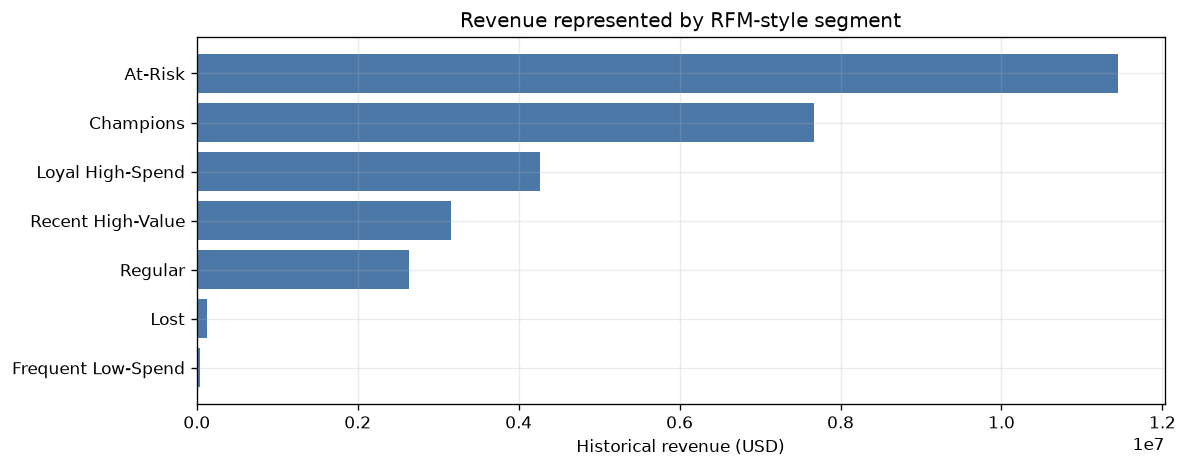

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_data = segments.sort_values("revenue")
ax.barh(plot_data["segment"], plot_data["revenue"], color="#4C78A8")
ax.set(title="Revenue represented by RFM-style segment", xlabel="Historical revenue (USD)", ylabel="")
fig.tight_layout()
fig.savefig(CHART_DIR / "q4_customer_segments.png", bbox_inches="tight")
plt.show()

**Observation:** the corrected segmentation places the newest dates in recency quintile 5. The At-Risk definition now refers to customers with older purchase dates and historically higher frequency or revenue.

**Hypothesis:** this group may be useful for a reactivation experiment, but the dataset does not contain contactability, campaign cost, or incremental lift.

**Data needed before action:** consent/contact status, prior campaign exposure, cost per contact, holdout/control groups, and post-campaign incremental revenue.

## 5. Which subcategories combine revenue and historical gross margin?

SQL compares revenue, product cost, gross profit, gross margin, and units sold by subcategory.

In [9]:
q5 = sql("SELECT * FROM analytics.q5_revenue_vs_margin ORDER BY revenue DESC")
q5[["category", "subcategory", "revenue", "gross_profit", "gross_margin_pct", "units_sold"]]

/tmp/ipykernel_94074/2098753172.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


,category,subcategory,revenue,gross_profit,gross_margin_pct,units_sold
0,Bikes,Road Bikes,"14,520,584.04","5,537,299.70",38.13,8068
1,Bikes,Mountain Bikes,"9,952,759.56","4,513,624.11",45.35,4970
2,Bikes,Touring Bikes,"3,844,801.05","1,454,872.70",37.84,2167
3,Accessories,Tires and Tubes,"245,529.32","153,700.75",62.60,17332
4,Accessories,Helmets,"225,335.60","141,059.83",62.60,6440
5,Clothing,Jerseys,"172,950.68","39,778.66",23.00,3332
6,Clothing,Shorts,"71,319.81","44,646.16",62.60,1019
7,Accessories,Bottles and Cages,"56,798.19","35,555.35",62.60,7981
8,Accessories,Fenders,"46,619.58","29,183.90",62.60,2121
9,Accessories,Hydration Packs,"40,307.67","25,232.57",62.60,733


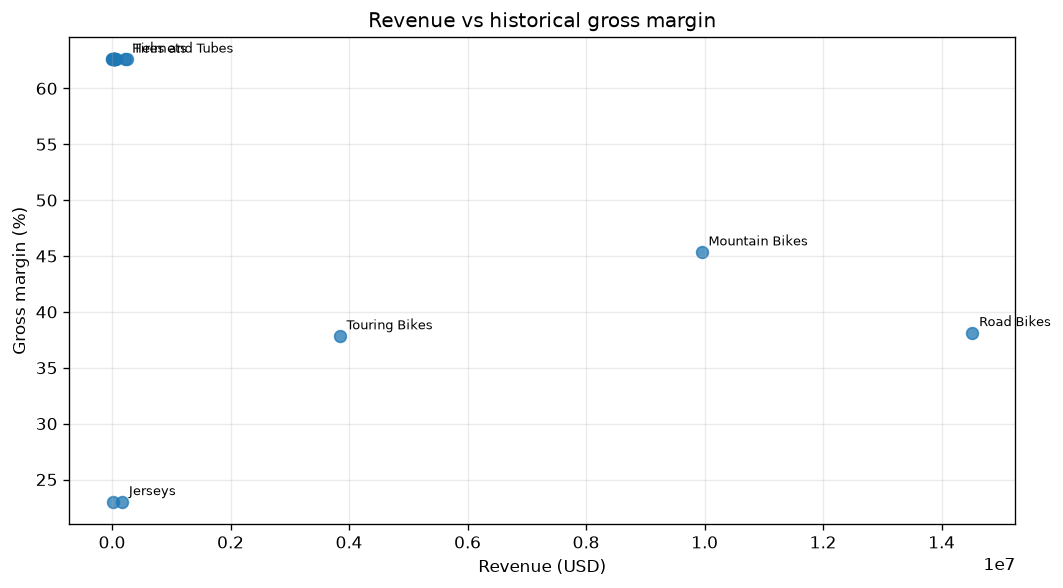

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(q5["revenue"], q5["gross_margin_pct"], s=50, alpha=0.75)
for _, row in q5.nlargest(6, "revenue").iterrows():
    ax.annotate(row["subcategory"], (row["revenue"], row["gross_margin_pct"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set(title="Revenue vs historical gross margin", xlabel="Revenue (USD)", ylabel="Gross margin (%)")
fig.tight_layout()
fig.savefig(CHART_DIR / "q5_revenue_vs_margin.png", bbox_inches="tight")
plt.show()

**Observation:** Road Bikes have the highest revenue among subcategories and a lower historical gross margin than several smaller categories. Accessories show high historical gross-margin percentages on a much smaller revenue base.

**Hypothesis:** Road Bikes may warrant a cost/price review, while Accessories may warrant a demand test. Neither conclusion follows from margin percentage alone.

**Data needed before action:** discounts, returns, freight allocation, overhead, price elasticity, inventory costs, and capacity constraints.

## Summary

| What the data shows | Working hypothesis | Additional evidence required |
|---|---|---|
| Basket size is stable by month | Mix/price may explain AOV differences | Promotions, prices, monthly product mix |
| 2012→2013 growth is concentrated in Bikes and several territories | Demand, launches, or availability may differ | Campaigns, launches, inventory, channel data |
| Top 20% of products represent ~70.8% of revenue | Availability of leading products may matter disproportionately | Stockouts, lead times, holding costs |
| Corrected RFM identifies older high-value/frequent customers | A controlled reactivation test may be worth evaluating | Contactability, campaign cost, control group |
| Road Bikes combine high revenue with lower historical margin | Price or cost structure may deserve investigation | Discounts, returns, full cost, elasticity |

The project intentionally stops at evidence-supported hypotheses rather than presenting unsupported business prescriptions.

In [11]:
conn.close()